# 08_get_binding_pocket_properties

Notebook for extracting binding-pocket properties with or without an explicit ligand.


## Python Path Setup


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_root = repo_root / "src"
if src_root.exists() and str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


## Imports


In [2]:
import importlib
import pandas as pd

import agentic_protein_design.steps.get_binding_pocket_properties as pocket_script
pocket_script = importlib.reload(pocket_script)

default_user_inputs = pocket_script.default_user_inputs
run_binding_pocket_property_extraction = pocket_script.run_binding_pocket_property_extraction


## Workflow Skeleton

1. Choose whether a ligand is present.
2. Run either `PocketAnalysis` or `LigandPocketAnalysis` from `tools/struct/`.
3. Inspect the generated binding-pocket property tables.


## User Inputs (Edit This Cell)


In [3]:
user_inputs = default_user_inputs()

# Data root key from project_config/variables.py (address_dict)
user_inputs["root_key"] = "examples" # 'ECOHARVEST' #
user_inputs["data_subfolder"] = "" # "lipases"

# Set True to use LigandPocketAnalysis, False to use PocketAnalysis
user_inputs["ligand_present"] = True

# Shared analysis settings
user_inputs["protein_molname"] = "A"
user_inputs["plot_properties"] = True
user_inputs["struct_csv_subdirectory_name"] = "structure_csv"

# Ligand-aware settings (used when ligand_present = True)
# ET096
user_inputs["ligand_molname"] = "D"
user_inputs["dist_thres"] = 8
user_inputs["reactive_center_target"] = [
    {"enz":'ET096', "cofactor":["FE"], "ligand":'N'},
    {"enz":'CviUPO', "cofactor":["FE"], "ligand":'N'},
    {"enz":'DcaUPO', "cofactor":["FE"], "ligand":'N'},
    {"enz":'TE314', "cofactor":["FE"], "ligand":'N'},
    {"OA167":'TE314', "cofactor":["FE"], "ligand":'N'},
]
# # RML/TLL
# user_inputs["ligand_molname"] = "B"
# user_inputs["dist_thres"] = 8
# user_inputs["reactive_center_target"] = [
#     {"enz":'RML', "protein":[144,203,257], "ligand":'O2'},
#     {"enz":'TLL', "protein":[146,201,258], "ligand":'O2'}
# ]
user_inputs["keep_pos_with_aa_variation_only"] = False
user_inputs["analyse_binding_pocket_without_ligand"] = True
user_inputs["seq_align_fname"] = "UPO_ali.fasta" # 'RML_TLL_ali.fasta' # "UPO_peroxygenation_ali.fasta"
user_inputs["binding_pocket_residues_fname"] = "residues_near_ligand.csv"
user_inputs["struct_dict"] = {
    # lipases
    # "RML": 'RML_SucroseOleate',
    # "TLL": "TLL_SucroseOleate",
    # UPOs
    "ET096": "ET096_S82",
    "CviUPO": "CviUPO_S82",
    "DcaUPO": "DcaUPO_S82",
    "TE314": "TE314_S82",
    "OA167": "OA167_S82",
}

# Ligand-free settings (used when ligand_present = False)
# pocket_residues_source = "csv": load {root}/pdb/{data_subfolder}/binding_pocket_residues_fname
# pocket_residues_source = "inline": use pocket_residues_dict below
user_inputs["pocket_residues_source"] = "csv"
user_inputs["pocket_residues_dict"] = {
    # "ET096": [69, 73, 158],
    # "CviUPO": [69, 73, 158],
}

user_inputs


{'root_key': 'examples',
 'data_subfolder': '',
 'ligand_present': True,
 'protein_molname': 'A',
 'ligand_molname': 'D',
 'dist_thres': 8,
 'reactive_center_target': [{'enz': 'ET096',
   'cofactor': ['FE'],
   'ligand': 'N'},
  {'enz': 'CviUPO', 'cofactor': ['FE'], 'ligand': 'N'},
  {'enz': 'DcaUPO', 'cofactor': ['FE'], 'ligand': 'N'},
  {'enz': 'TE314', 'cofactor': ['FE'], 'ligand': 'N'},
  {'OA167': 'TE314', 'cofactor': ['FE'], 'ligand': 'N'}],
 'keep_pos_with_aa_variation_only': False,
 'plot_properties': True,
 'analyse_binding_pocket_without_ligand': True,
 'seq_align_fname': 'UPO_ali.fasta',
 'binding_pocket_residues_fname': 'residues_near_ligand.csv',
 'struct_csv_subdirectory_name': 'structure_csv',
 'pocket_residues_source': 'csv',
 'pocket_residues_dict': {},
 'struct_dict': {'ET096': 'ET096_S82',
  'CviUPO': 'CviUPO_S82',
  'DcaUPO': 'DcaUPO_S82',
  'TE314': 'TE314_S82',
  'OA167': 'OA167_S82'}}

## Run Binding Pocket Property Extraction


struct_fpaths: 5
[PosixPath('/Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/ET096_S82.pdb'), PosixPath('/Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/CviUPO_S82.pdb'), PosixPath('/Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/DcaUPO_S82.pdb'), PosixPath('/Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/TE314_S82.pdb'), PosixPath('/Users/charmainechia/Documents/projects/agentic-protein-design/examples/pdb/OA167_S82.pdb')]
Ref Object: ET096_S82.pdb (243 residues) 

CviUPO_S82.pdb (226 residues)
TM-align score: None
RMSD (superposed residues): 0
RMSD (aligned residues): 1.12
# of aligned residues: 205/226 (90.7%)
[IDENTICAL] all: 68 (33.2%); hydrophobic: 24 (11.7%); non-hydrophobic: 44 (21.5%)
[SIMILAR] all: 126 (61.5%); hydrophobic: 60 (29.3%); non-hydrophobic: 66 (32.2%)

DcaUPO_S82.pdb (222 residues)
TM-align score: None
RMSD (superposed residues): 0.73
RMSD (aligned resid

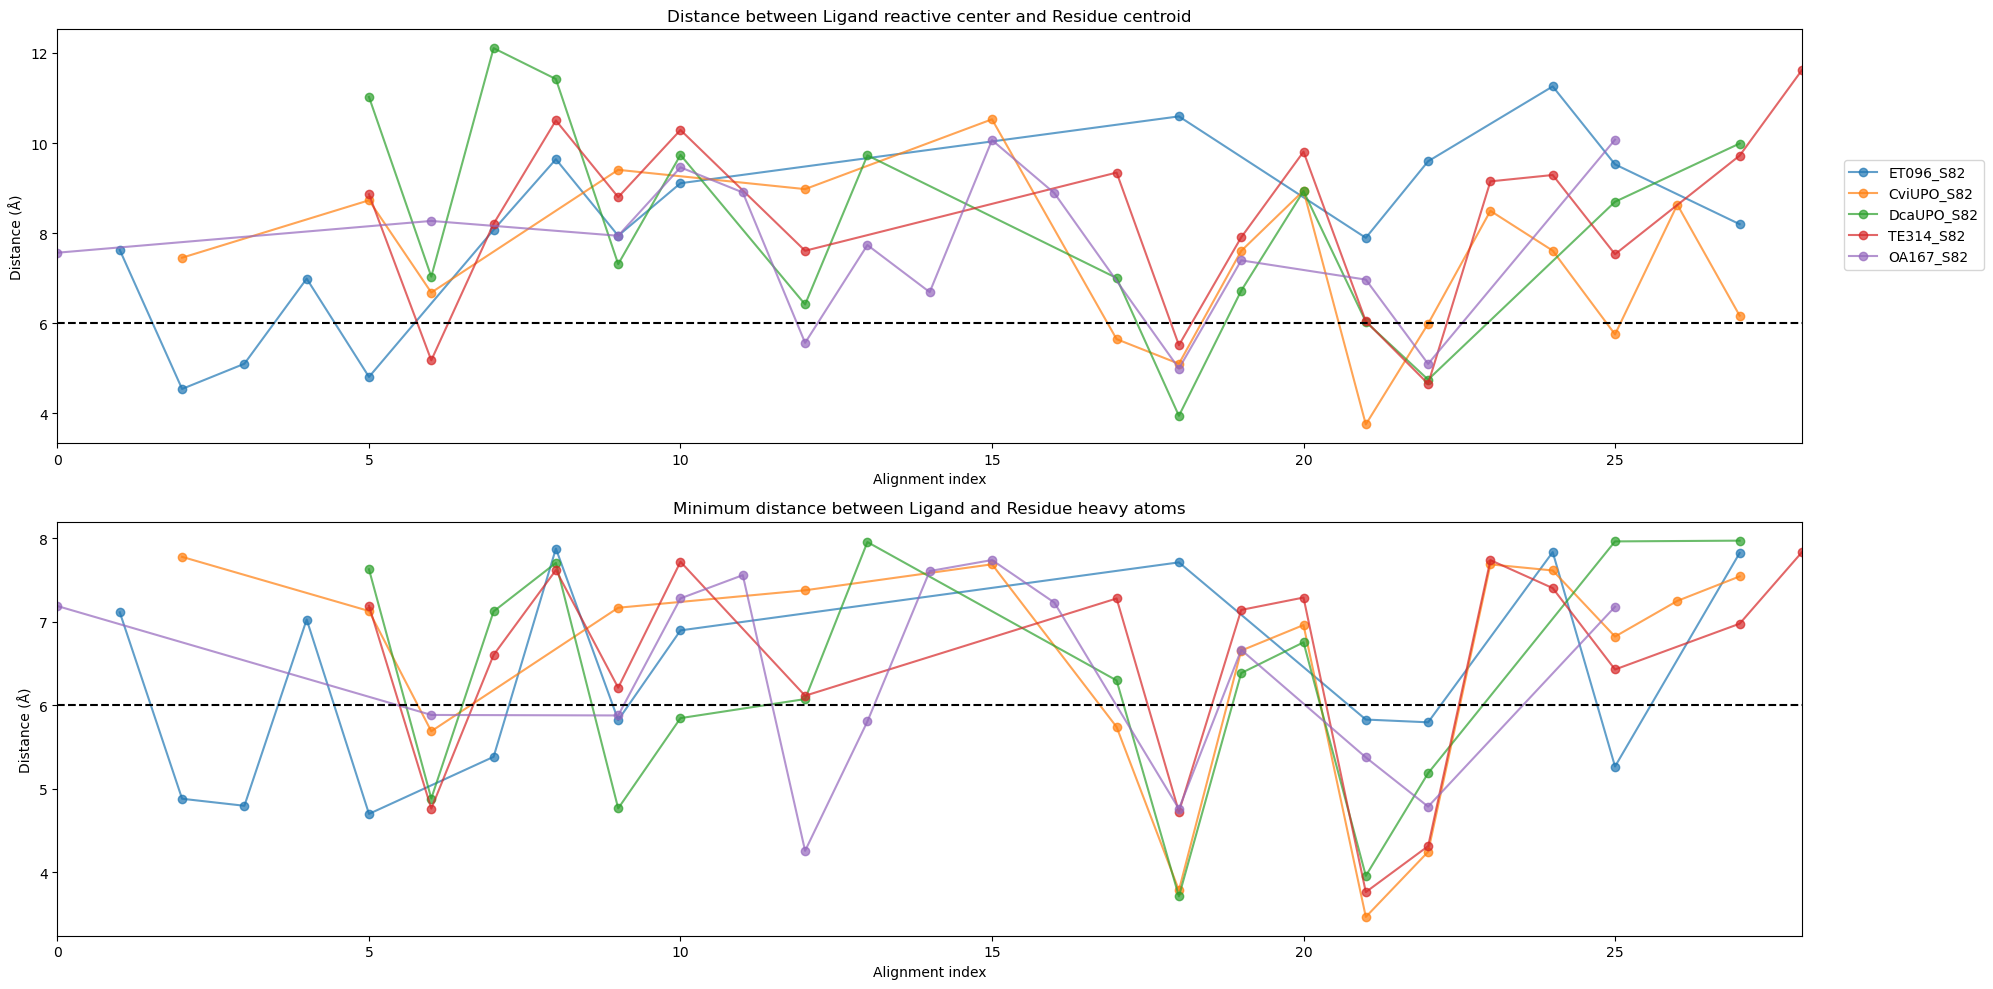

* 1 100 74V 57L 55L 77L 73T 4.881 7.776 8.503 8.514 8.851
* 2 103 77A 60T 58D 80T 76A 4.7 7.128 7.627 7.191 8.648
* 3 104 - 61I 59L 81L 77L nan 5.689 4.884 4.763 5.884
* 4 105 78F 62S 60H 82G 78A 5.383 9.306 7.123 6.602 9.015
* 5 106 79M 63T 61T 83T 79T 7.875 9.807 7.703 7.618 9.48
* 6 107 80A 64L 62F 84P 80L 5.823 7.167 4.766 6.21 5.878
* 7 108 81A 65G 63A 85A 81G 6.896 8.792 5.846 7.717 7.279
* 8 138 103I 88F 86L 108I 104I 8.283 7.376 6.074 6.114 4.258
  9 139 104E 89E 87E 109E 105E 10.584 8.956 7.953 8.344 5.806
* 10 215 168V 154Q 150L 179S 170N 10.344 7.687 8.981 9.419 7.738
* 11 218 - 157I 153G 182T 173F nan 5.74 6.297 7.278 8.092
* 12 219 171A 158T 154F 183V 174P 7.71 3.786 3.713 4.725 4.76
* 13 220 172S 159S 155G 184S 175T 9.44 6.654 6.385 7.141 6.663
* 14 221 173A 160Y 156L 185L 176Y 9.527 6.96 6.753 7.289 8.487
* 15 222 174L 161G 157G 186G 177F 5.829 3.467 3.959 3.764 5.376
  16 223 175E 162E 158E 187E 178E 5.796 4.246 5.187 4.314 4.787
* 17 224 176T 163T 159T 188S 179S 8.959 

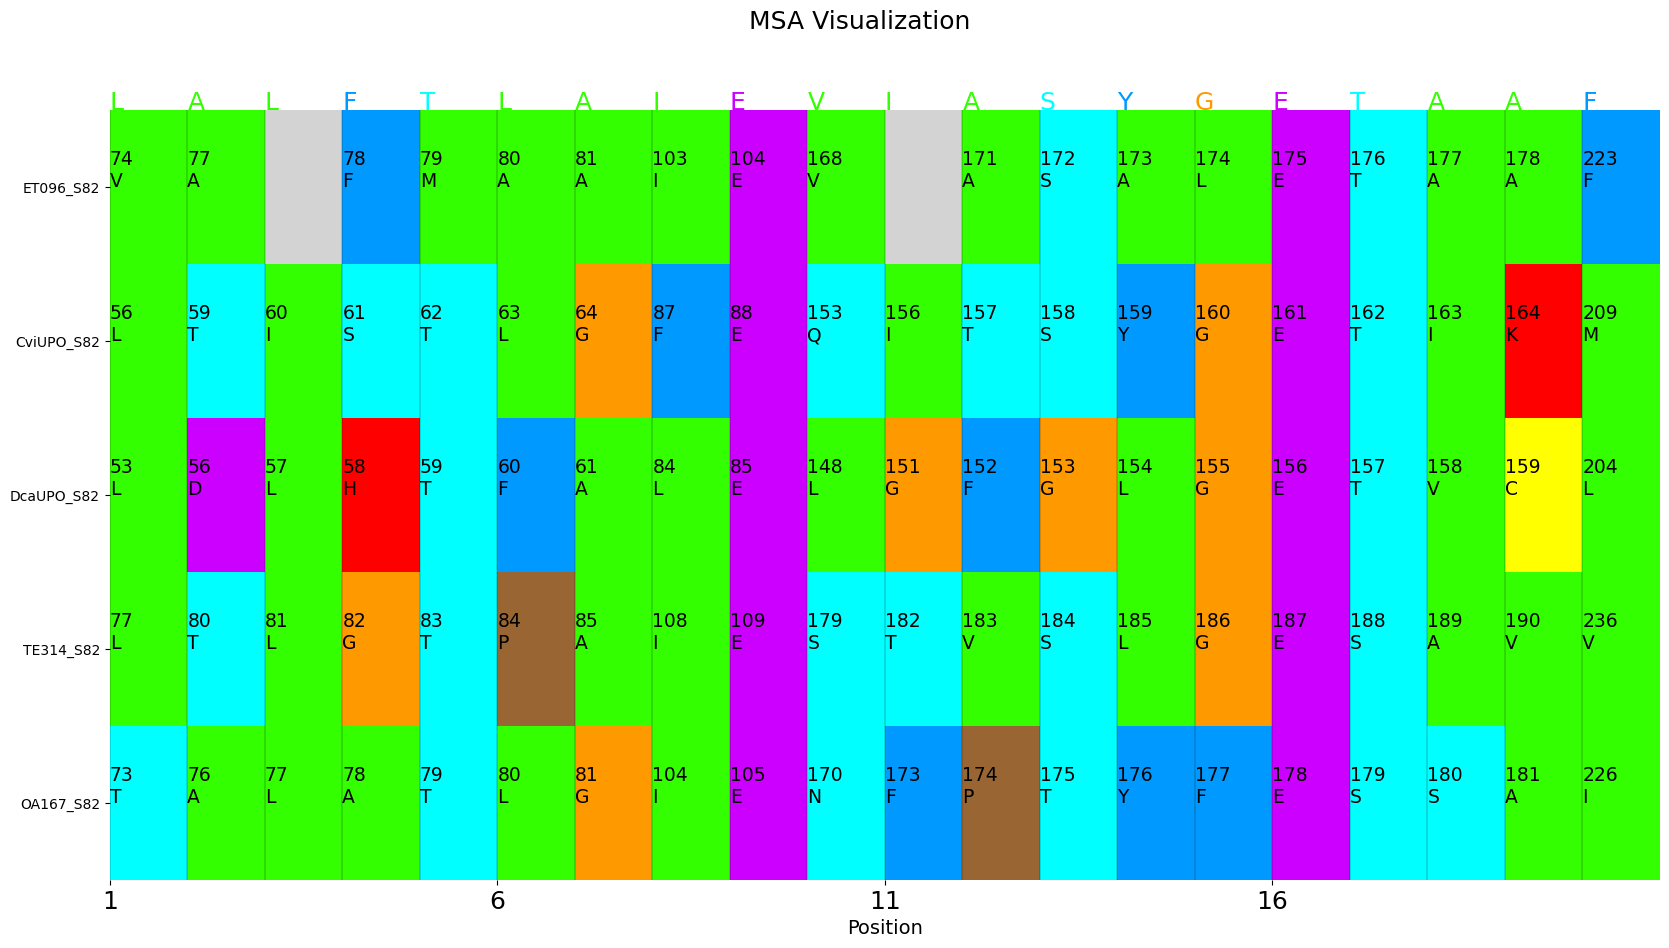

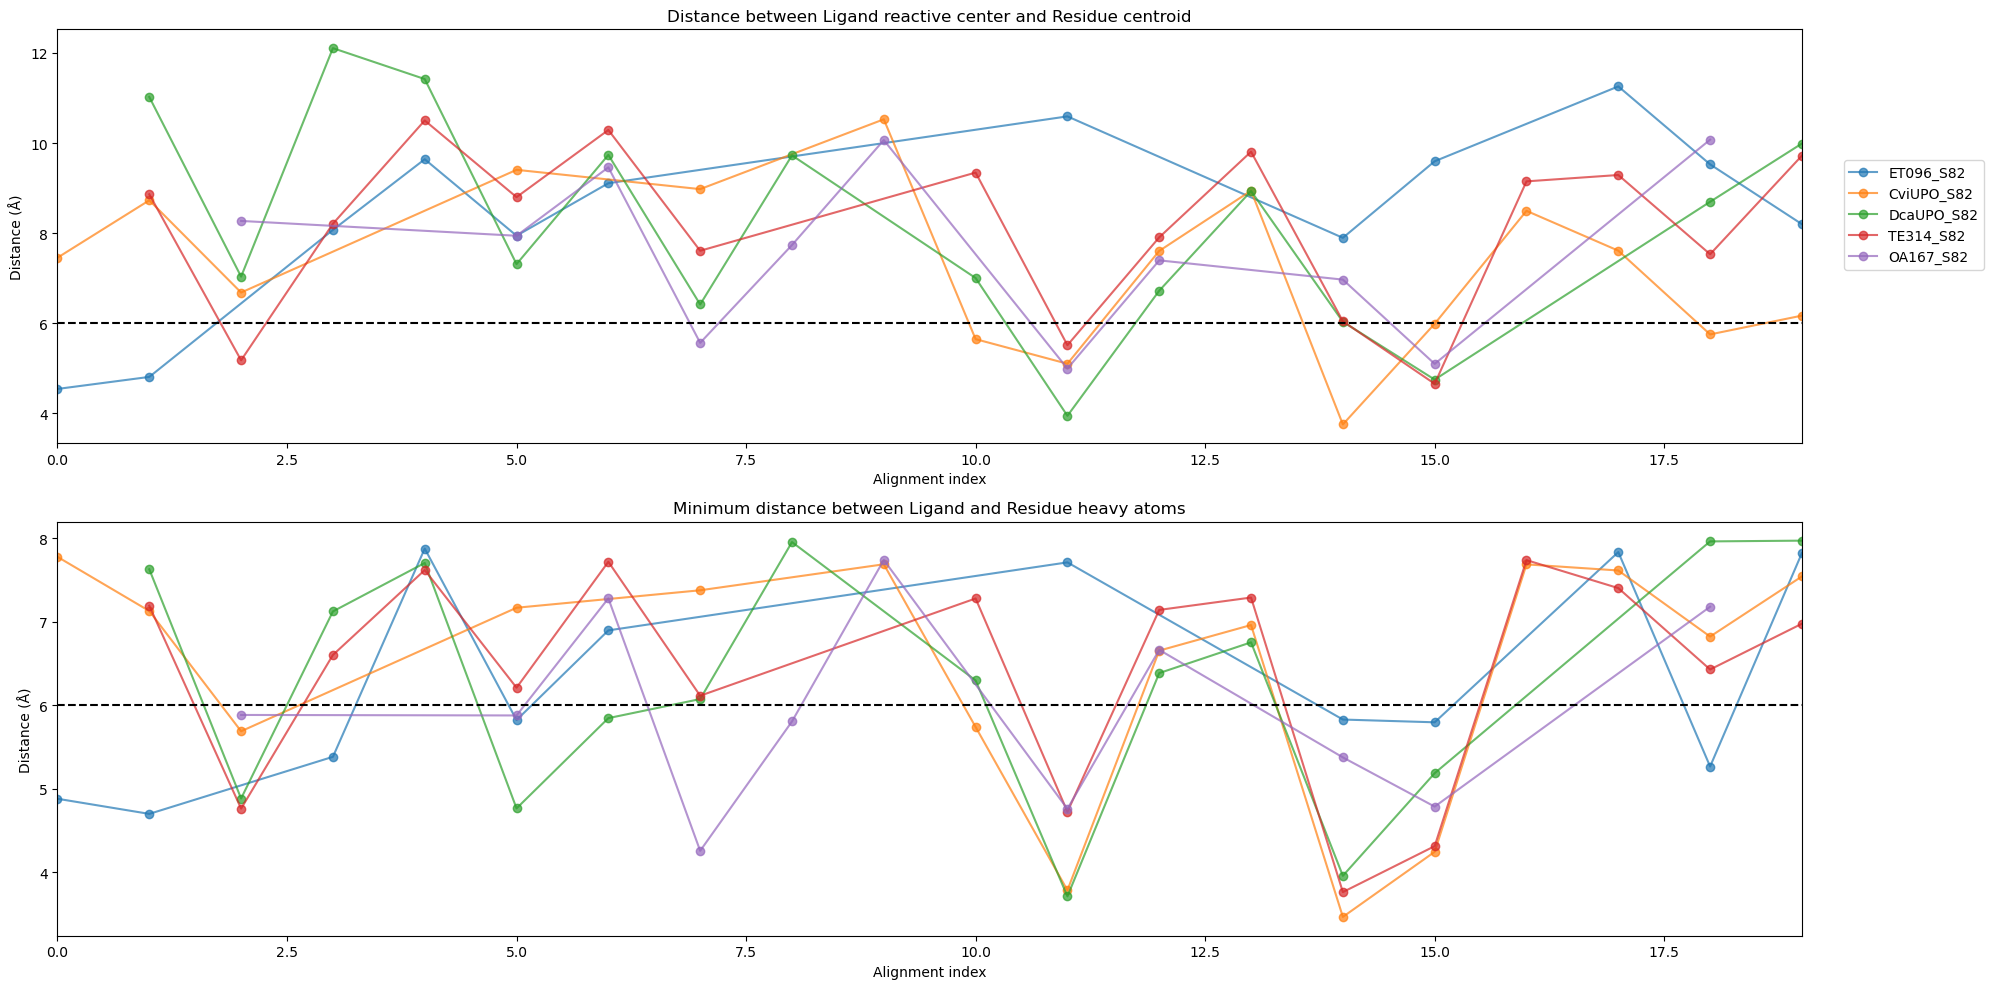

Saved all aligned proteins to YASARA scene: /Users/charmainechia/Documents/projects/agentic-protein-design/examples/sce/UPO_ali.sce
Saved ET096 to YASARA scene.
Saved CviUPO to YASARA scene.
Saved DcaUPO to YASARA scene.
Saved TE314 to YASARA scene.
Saved OA167 to YASARA scene.
Obtaining distal pocket properties...
[ET096_S82] Binding pocket residues (13): [70, 75, 76, 78, 79, 80, 81, 171, 174, 175, 177, 178, 223]
Centroid: [-10.48752747  -3.13491209  -0.80692308]
--- All Residue Atoms ---
Mean distance to binding pocket centroid: 8.5723
Mean MIN distance to binding pocket centroid: 7.2072
--- Backbone Only ---
Mean distance to binding pocket centroid: 8.4489
Mean MIN distance to binding pocket centroid: None

[CviUPO_S82] Binding pocket residues (16): [57, 60, 61, 64, 88, 154, 157, 158, 159, 160, 162, 163, 164, 165, 207, 210]
Centroid: [-10.04503101   1.15191473   2.41351163]
--- All Residue Atoms ---
Mean distance to binding pocket centroid: 7.7278
Mean MIN distance to binding pocket

In [4]:
result = run_binding_pocket_property_extraction(user_inputs)
print("status:", result.get("status", ""))
print("ligand_present:", result.get("ligand_present", ""))
print("combined_analysis_path:", result.get("combined_analysis_path", ""))
